In [125]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import OpenEXR
import Imath

In [126]:
APERTURE_SHAPE_PATH = r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\Assets\NoiseTextures\UniformStar\UniformStar.png"
APERTURE_OPEN_THRESHOLD = 0.5
_aperture_texture = None

def load_aperture_texture():
    global _aperture_texture
    if _aperture_texture is None:
        _aperture_texture = np.asarray(Image.open(APERTURE_SHAPE_PATH).convert("L"), dtype=np.float32) / 255.0
    return _aperture_texture

In [127]:
N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.67270, 1.64238, 1.64238]

helios_to_biotar = scale * sum([10.75, 15.55, 5.05, 5.05, 21.22, 13.9, 1.65, 18.9, 0.97]) / 40.0
APERTURE_RADIUS = 0.5 * 20.0 * helios_to_biotar  # widest aperture diameter = 20mm

r_front = 15.0 * helios_to_biotar   # r1-r4
r_mid5 = 10.0 * helios_to_biotar    # r5
r_mid6 = 9.5 * helios_to_biotar     # r6
r_back = 12.5 * helios_to_biotar    # r7-r10

LENS = list(zip(
    [curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [r_front, r_front, r_front, r_front, r_mid5, APERTURE_RADIUS, r_mid6, r_back, r_back, r_back, r_back]
))

TEXTURED_APERTURE_INDEX = 5

def compute_lens_surfaces():
    z, media_before, media_after = 0.0, [], []
    surfaces, medium_before = [], N_AIR
    for curvature, thickness, n_next, _ in LENS:
        surfaces.append(z)
        media_before.append(medium_before)
        media_after.append(n_next)
        medium_before = n_next
        z += thickness
    return np.array(surfaces), np.array(media_before), np.array(media_after)

LENS_SURFACE_Z, LENS_MEDIA_BEFORE, LENS_MEDIA_AFTER = compute_lens_surfaces()

t_focus_distance = 45.0
SENSOR_PLANE_OFFSET = 335.598 / (t_focus_distance + 15.4) + 37.887
Z_ORIGIN_SHIFT = LENS_SURFACE_Z[-1] + SENSOR_PLANE_OFFSET
LENS_SURFACE_Z = LENS_SURFACE_Z - Z_ORIGIN_SHIFT
SENSOR_PLANE_Z = 0.0
APERTURE_Z = LENS_SURFACE_Z[TEXTURED_APERTURE_INDEX]
RAY_EXTENSION = 60.0

def aperture_allows(hit, aperture_radius, element_index):
    if aperture_radius <= 0.0 or element_index != TEXTURED_APERTURE_INDEX:
        return True
    x, y = hit[0], hit[1]
    if x * x + y * y > aperture_radius * aperture_radius:
        return False
    texture = load_aperture_texture()
    h, w = texture.shape
    u, v = 0.5 + 0.5 * x / aperture_radius, 0.5 + 0.5 * y / aperture_radius
    if not (0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return False
    return texture[int(round(v * (h - 1))), int(round(u * (w - 1)))] <= APERTURE_OPEN_THRESHOLD

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    return eta * direction + (eta * cos_i - np.sqrt(max(0.0, 1.0 - sin2_t))) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, -1.0 if direction[2] > 0 else 1.0])
        return hit, normal
    
    radius = abs(curvature)
    center_z = z_surface + curvature
    oc = origin - np.array([0.0, 0.0, center_z])
    a, b, c = np.dot(direction, direction), np.dot(oc, direction), np.dot(oc, oc) - radius * radius
    if a <= 1e-12:
        return None
    disc = b * b - a * c
    if disc < 0.0:
        return None
    
    sqrt_disc = np.sqrt(disc)
    t0, t1 = (-b - sqrt_disc) / a, (-b + sqrt_disc) / a
    use_closer = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = min(t0, t1) if use_closer else max(t0, t1)
    if t <= 0.0:
        return None
    
    hit = origin + t * direction
    normal = (hit - np.array([0.0, 0.0, center_z])) / radius
    return hit, normal if use_closer else -normal

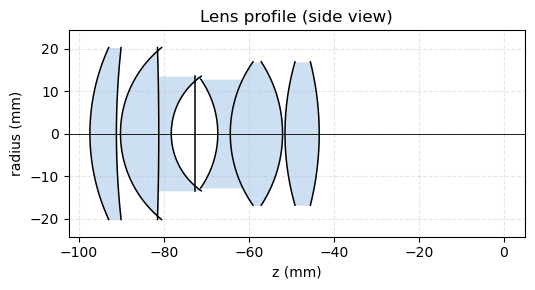

In [128]:
def spherical_profile(curvature, z_surface, aperture, samples=240):
    if aperture <= 0.0:
        return None
    r = np.linspace(-aperture, aperture, samples)
    if abs(curvature) < 1e-9:
        return np.full_like(r, z_surface), r
    radius = abs(curvature)
    sag = np.sqrt(np.clip(radius * radius - r * r, 0.0, None))
    return z_surface + curvature - np.sign(curvature) * sag, r

def add_lens_profile(ax, samples=240):
    surfaces, z = [], LENS_SURFACE_Z[0]
    for curvature, thickness, n_next, aperture in LENS:
        profile = spherical_profile(curvature, z, aperture, samples)
        surfaces.append((curvature, z, aperture, n_next))
        if profile:
            ax.plot(profile[0], profile[1], color="black", linewidth=1.1)
        z += thickness
    for i in range(len(surfaces) - 1):
        c_a, z_a, ap_a, n = surfaces[i]
        c_b, z_b, ap_b, _ = surfaces[i + 1]
        if n <= N_AIR + 1e-6:
            continue
        ap = min(ap_a, ap_b)
        if ap <= 0.0:
            continue
        p_a, p_b = spherical_profile(c_a, z_a, ap, samples), spherical_profile(c_b, z_b, ap, samples)
        if p_a and p_b:
            ax.fill_betweenx(p_a[1], np.minimum(p_a[0], p_b[0]), np.maximum(p_a[0], p_b[0]), color="#71a7dd", alpha=0.35, linewidth=0)

fig, ax = plt.subplots(figsize=(8.0, 3.0))
add_lens_profile(ax)
ax.axhline(0, color="black", linewidth=0.6)
ax.set(title="Lens profile (side view)", xlabel="z (mm)", ylabel="radius (mm)", xlim=(LENS_SURFACE_Z[0] - 5, 5), ylim=(-APERTURE_RADIUS * 1.8, APERTURE_RADIUS * 1.8), aspect="equal")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
def trace_ray(origin, target):
    origin, direction = np.array(origin, dtype=float), np.array(target, dtype=float) - origin
    path = [origin.copy()]
    norm = np.linalg.norm(direction)
    if norm == 0:
        return None, path
    direction /= norm
    n_current = LENS_MEDIA_AFTER[-1]
    for idx in range(len(LENS) - 1, -1, -1):
        result = intersect_surface(origin, direction, LENS[idx][0], LENS_SURFACE_Z[idx])
        if result is None:
            return None, path
        hit, normal = result
        path.append(hit.copy())
        if LENS[idx][3] > 0 and not aperture_allows(hit, LENS[idx][3], idx):
            return None, path
        n_target = LENS_MEDIA_BEFORE[idx]
        if n_target <= 0:
            return None, path
        refracted = refract(direction, normal, n_current / n_target)
        if refracted is None:
            return None, path
        direction = refracted / np.linalg.norm(refracted)
        origin, n_current = hit, n_target
    return {"position": origin, "direction": direction}, path

In [130]:
SENSOR_WIDTH = 36.0   # mm (3:2 aspect)
SENSOR_HEIGHT = 24.0  # mm

In [131]:
def trace_to_aperture(origin, target):
    origin, direction = np.array(origin, dtype=float), np.array(target, dtype=float) - origin
    norm = np.linalg.norm(direction)
    if norm == 0:
        return np.inf, None
    direction /= norm
    n_current = LENS_MEDIA_AFTER[-1]
    for idx in range(len(LENS) - 1, TEXTURED_APERTURE_INDEX - 1, -1):
        result = intersect_surface(origin, direction, LENS[idx][0], LENS_SURFACE_Z[idx])
        if result is None:
            return np.inf, None
        hit, normal = result
        if idx == TEXTURED_APERTURE_INDEX:
            return np.linalg.norm(hit[:2]), hit
        n_target = LENS_MEDIA_BEFORE[idx]
        if n_target <= 0:
            return np.inf, None
        refracted = refract(direction, normal, n_current / n_target)
        if refracted is None:
            return np.inf, None
        direction = refracted / np.linalg.norm(refracted)
        origin, n_current = hit, n_target
    return np.inf, None

def find_aperture_direction(film_point, tol=1e-4, max_iters=100):
    film_point = np.array(film_point, dtype=float)
    target = np.array([0.0, 0.0, LENS_SURFACE_Z[-1]])
    step = 0.5 * abs(LENS[-1][3]) if LENS[-1][3] > 0 else 0.5 * APERTURE_RADIUS
    best_loss, _ = trace_to_aperture(film_point, target)
    
    diag = np.array([SENSOR_WIDTH, SENSOR_HEIGHT, 0.0])
    diag /= np.linalg.norm(diag[:2])
    step_dirs = [np.array([1,0,0]), np.array([-1,0,0]), np.array([0,1,0]), np.array([0,-1,0]), diag, -diag]
    
    for _ in range(max_iters):
        if best_loss <= tol and step <= tol:
            break
        improved = False
        for v in step_dirs:
            loss, _ = trace_to_aperture(film_point, target + step * v)
            if loss < best_loss:
                best_loss, target, improved = loss, target + step * v, True
        step *= 0.5
        if not improved and step <= tol:
            break
    d = target - film_point
    norm = np.linalg.norm(d)
    return d / norm if norm > 0 else None

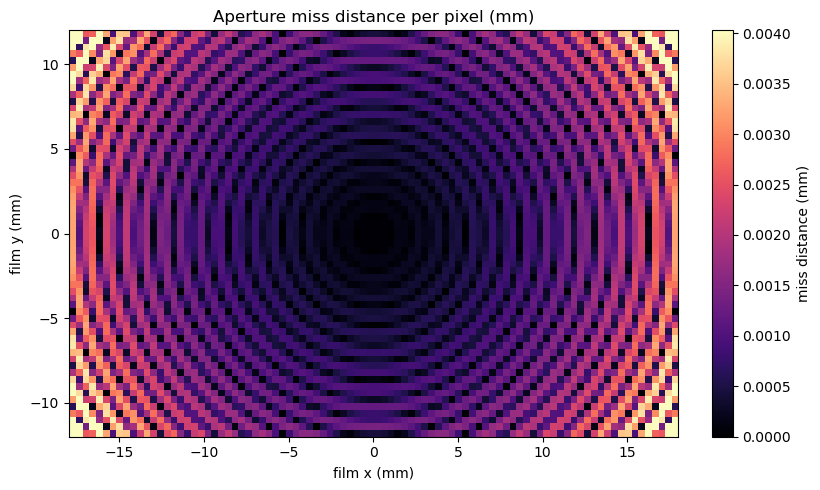

In [132]:
def build_diagonal_lookup(num_samples=21, tol=1e-10, max_iters=32):
    radii, dirs = [], []
    for i in range(num_samples):
        t = i / (num_samples - 1) if num_samples > 1 else 0.0
        pt = np.array([t * 0.5 * SENSOR_WIDTH, t * 0.5 * SENSOR_HEIGHT, SENSOR_PLANE_Z])
        d = find_aperture_direction(pt, tol=tol, max_iters=max_iters)
        if d is not None:
            radii.append(np.linalg.norm(pt[:2]))
            dirs.append(d)
    if not radii:
        return None
    order = np.argsort(radii)
    return {"radii": np.array(radii)[order], "dirs": np.array(dirs)[order], "base_angle": np.arctan2(SENSOR_HEIGHT, SENSOR_WIDTH)}

def direction_from_lookup(lookup, film_point):
    if lookup is None:
        return None
    radii, dirs, base_angle = lookup["radii"], lookup["dirs"], lookup["base_angle"]
    r = np.linalg.norm(film_point[:2])
    r_clamped = np.clip(r, radii[0], radii[-1])
    d = np.array([np.interp(r_clamped, radii, dirs[:, k]) for k in range(3)])
    d /= np.linalg.norm(d)
    if r > 0:
        rot = np.arctan2(film_point[1], film_point[0]) - base_angle
        c, s = np.cos(rot), np.sin(rot)
        d = np.array([c * d[0] - s * d[1], s * d[0] + c * d[1], d[2]])
        d /= np.linalg.norm(d)
    return d

def pixel_to_film(i, j, w, h):
    sx, sy = (2.0 * i + 1.0) / w - 1.0, (2.0 * j + 1.0) / h - 1.0
    return -sx * SENSOR_WIDTH * 0.5, -sy * SENSOR_HEIGHT * 0.5

def solve_sensor_grid(width_px=90, height_px=60, diag_samples=21):
    lookup = build_diagonal_lookup(diag_samples)
    directions = np.full((height_px, width_px, 3), np.nan)
    for j in range(height_px):
        for i in range(width_px):
            x, y = pixel_to_film(i, j, width_px, height_px)
            d = direction_from_lookup(lookup, np.array([x, y, SENSOR_PLANE_Z]))
            if d is not None:
                directions[j, i] = d
    return directions

dir_map = solve_sensor_grid()
loss_map = np.full(dir_map.shape[:2], np.nan)
lookup = build_diagonal_lookup(21)
for j in range(dir_map.shape[0]):
    for i in range(dir_map.shape[1]):
        x, y = pixel_to_film(i, j, dir_map.shape[1], dir_map.shape[0])
        pt = np.array([x, y, SENSOR_PLANE_Z])
        if not np.isnan(dir_map[j, i]).any():
            loss, _ = trace_to_aperture(pt, pt + dir_map[j, i] * 100)
            loss_map[j, i] = loss

fig, ax = plt.subplots(figsize=(9.5, 5.0))
extent = [-0.5 * SENSOR_WIDTH, 0.5 * SENSOR_WIDTH, -0.5 * SENSOR_HEIGHT, 0.5 * SENSOR_HEIGHT]
im = ax.imshow(loss_map, origin="lower", extent=extent, cmap="magma", vmin=0.0, vmax=np.nanpercentile(loss_map, 99))
ax.set(xlabel="film x (mm)", ylabel="film y (mm)", title="Aperture miss distance per pixel (mm)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="miss distance (mm)")
plt.tight_layout()
plt.show()

Plotted 345 rays


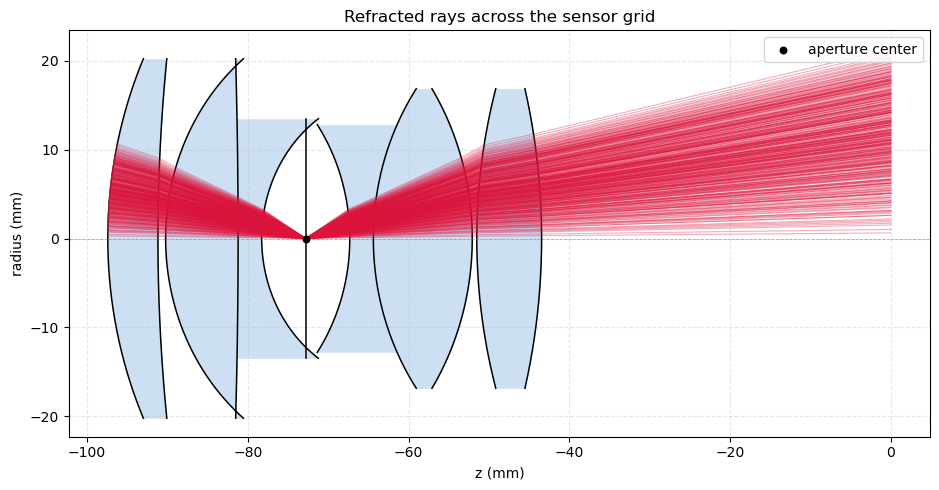

In [133]:
def plot_grid_rays(width_px=90, height_px=60, stride=4, max_rays=2000):
    directions = solve_sensor_grid(width_px, height_px)
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    add_lens_profile(ax)
    count = 0
    for j in range(0, height_px, stride):
        for i in range(0, width_px, stride):
            if count >= max_rays or np.isnan(directions[j, i]).any():
                continue
            x, y = pixel_to_film(i, j, width_px, height_px)
            film_pt = np.array([x, y, SENSOR_PLANE_Z])
            result, path = trace_ray(film_pt, film_pt + directions[j, i] * travel)
            if result:
                path = np.array(path)
                ax.plot(path[:, 2], np.linalg.norm(path[:, :2], axis=1), color="crimson", alpha=0.35, linewidth=0.8)
                count += 1
    ax.scatter([APERTURE_Z], [0], color="black", s=22, label="aperture center", zorder=5)
    ax.set(xlabel="z (mm)", ylabel="radius (mm)", title="Refracted rays across the sensor grid")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    print(f"Plotted {count} rays")
    return fig, ax

fig_grid, ax_grid = plot_grid_rays()

In [135]:
def write_exr(filepath, data):
    h, w = data.shape
    header = OpenEXR.Header(w, h)
    header['channels'] = {'Y': Imath.Channel(Imath.PixelType(Imath.PixelType.FLOAT))}
    out = OpenEXR.OutputFile(filepath, header)
    out.writePixels({'Y': data.astype(np.float32).tobytes()})
    out.close()

def export_exit_maps(width_px=90, height_px=60, base_dir=r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\lens_distortion"):
    directions = solve_sensor_grid(width_px, height_px)
    os.makedirs(base_dir, exist_ok=True)
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION
    pos = np.full((height_px, width_px, 3), np.nan, dtype=np.float32)
    dirs = np.full((height_px, width_px, 3), np.nan, dtype=np.float32)
    
    for j in range(height_px):
        for i in range(width_px):
            if np.isnan(directions[j, i]).any():
                continue
            x, y = pixel_to_film(i, j, width_px, height_px)
            film_pt = np.array([x, y, SENSOR_PLANE_Z])
            result, path = trace_ray(film_pt, film_pt + directions[j, i] * travel)
            if result and len(path) >= 2:
                pos[j, i] = path[1]
                dirs[j, i] = result["direction"]
    
    for k, c in enumerate("xyz"):
        write_exr(os.path.join(base_dir, f"exit_position_{c}.exr"), pos[:, :, k])
        write_exr(os.path.join(base_dir, f"exit_direction_{c}.exr"), dirs[:, :, k])
    
    print(f"Saved EXRs to {base_dir}")
    return pos, dirs

pos_map, dir_map = export_exit_maps(90, 60)

Saved EXRs to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\lens_distortion
